In [14]:
!export CUDNN_PATH=$(dirname $(python3.12 -c "import nvidia.cudnn;print(nvidia.cudnn.__file__)"))
!export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:$CONDA_PREFIX/lib

In [13]:
import struct
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix

In [ ]:
with open('./datasets/mnist/train-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    train_images = np.fromfile(f, dtype=np.uint8).reshape(n, rows, cols, 1)  # NHWC: (이미지 수(n), 높이(rows), 너비(cols), Channel 수)

with open('./datasets/mnist/train-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    train_labels = np.fromfile(f, dtype=np.uint8)

with open('./datasets/mnist/t10k-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    test_images = np.fromfile(f, dtype=np.uint8).reshape(n, rows, cols, 1)

with open('./datasets/mnist/t10k-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    test_labels = np.fromfile(f, dtype=np.uint8)

# uint8(0 ~ 255) -> float32(0.0 ~ 1.0) Normalization
train_images = train_images.astype(np.float32) / 255.0
test_images  = test_images.astype(np.float32)  / 255.0

In [16]:
# numpy array pair (image, label) -> tf.data.Dataset 변환
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
test_dataset  = tf.data.Dataset.from_tensor_slices((test_images, test_labels))

# prefetch(): 다음 batch를 background에서 미리 load -> GPU 대기 시간 감소
train_dataset = train_dataset.shuffle(1000).batch(64).prefetch(tf.data.AUTOTUNE)
test_dataset  = test_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

In [17]:
model = keras.Sequential([
    
    # (28, 28, 1) -> (28*28*1, ) : Dense layer는 1d input을 받으므로, 먼저 Flattening
    keras.layers.Flatten(input_shape=(28, 28, 1)),  # [N, 28, 28, 1] → [N, 784]

    # 784 -> 512, ReLU: 음수 제거로 비선형성 추가
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.3),  # 학습 시 30% 뉴런 무작위 비활성화 -> 과적합 방지

    keras.layers.Dense(256, activation='relu'),  # 512 -> 256
    keras.layers.Dropout(0.3),

    keras.layers.Dense(128, activation='relu'),  # 256 -> 128
    keras.layers.Dropout(0.3),

    # softmax: 10개 class -> 합이 1인 확률분포로 변환 (각 class에 대한 예측 확률)
    keras.layers.Dense(10, activation='softmax')    # 출력 10개 = 클래스 수(0~9)
])

model.summary()

/home/ec2-user/.local/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # Adam optimizer
    loss='sparse_categorical_crossentropy',  # label이 one-hot이 아닌 정수인 경우 사용하는 loss function
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9063 - loss: 0.3099 - val_accuracy: 0.9620 - val_loss: 0.1260
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9580 - loss: 0.1443 - val_accuracy: 0.9690 - val_loss: 0.1031
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9666 - loss: 0.1129 - val_accuracy: 0.9709 - val_loss: 0.1014
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9735 - loss: 0.0902 - val_accuracy: 0.9763 - val_loss: 0.0832
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9764 - loss: 0.0804 - val_accuracy: 0.9765 - val_loss: 0.0810
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9792 - loss: 0.0690 - val_accuracy: 0.9775 - val_loss: 0.0810
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9799 - loss: 0.0653 - val_accuracy: 0.9780 - val_loss: 0.0773
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9819 - loss: 0.0614 - val_accuracy: 0.

In [20]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2%}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9803 - loss: 0.0764
Test Loss: 0.0764 | Test Acc: 98.03%


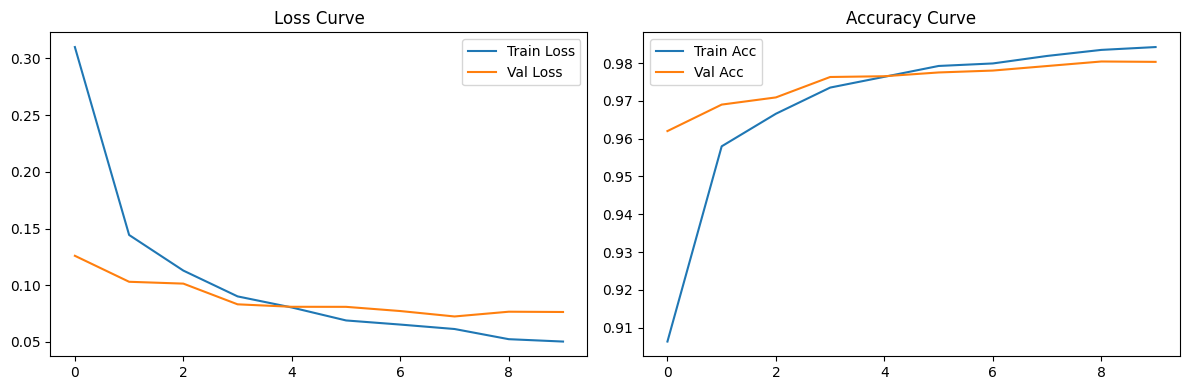

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# history.history: {'loss': [...], 'val_loss': [...], 'accuracy': [...], 'val_accuracy': [...]}
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

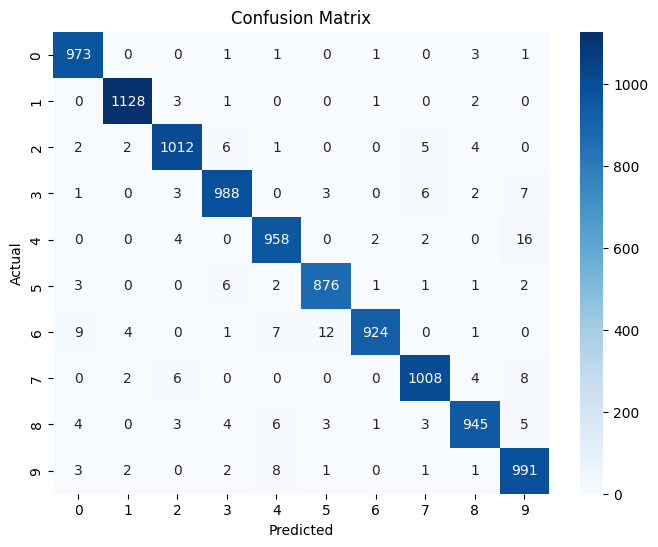

In [22]:
all_preds, all_labels = [], []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

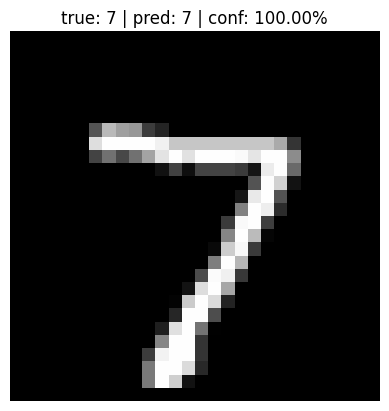

In [23]:
sample_image = test_images[0:1]   # (1, 28, 28, 1)
true_label   = test_labels[0]

probs      = model.predict(sample_image, verbose=0)[0]
pred_label = np.argmax(probs)
confidence = probs[pred_label]

plt.imshow(test_images[0].squeeze(), cmap='gray')
plt.title(f"true: {true_label} | pred: {pred_label} | conf: {confidence:.2%}")
plt.axis('off')
plt.show()